<!-- @format -->

# Phân Tích Kích Thước Ảnh - ImageNet-Hard Dataset

## Vấn đề chính

Kiểm tra xem dataset của chúng ta có phù hợp với yêu cầu kích thước đầu vào của mô hình **EfficientNet-V2-L** hay không.

### EfficientNet-V2-L yêu cầu:

- **Input size: 480x480 pixels**
- Feature dimension: 1280
- Transform pipeline: Resize(512) → CenterCrop(480) → Normalize

### Câu hỏi:

- Có bao nhiêu ảnh là 480x480?
- Phân bố kích thước ảnh thế nào?
- Mô hình xử lý ảnh khác kích thước như thế nào?


In [4]:
# Import libraries
import pandas as pd
import numpy as np
import glob
import os
from PIL import Image
import io
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

<!-- @format -->

## 1. Load Dataset và Phân Tích Kích Thước Ảnh


In [5]:
# Load dataset từ parquet files
files = glob.glob(os.path.join('../data', '*.parquet'))
print(f"Found {len(files)} parquet files")

df = pd.concat((pd.read_parquet(f) for f in files), ignore_index=True)
print(f"Total images in dataset: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

Found 9 parquet files
Total images in dataset: 10980
Columns: ['image', 'label', 'origin', 'english_label']


In [6]:
# Function to extract image size
def get_image_size(img_bytes):
    """Extract (width, height) từ image bytes"""
    try:
        img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
        return img.size
    except Exception as e:
        print(f"Error reading image: {e}")
        return None

# Extract sizes from all images
print("Extracting image sizes")
sizes = []
failed_count = 0

for idx, img_bytes in enumerate(df['image'].apply(lambda x: x['bytes'])):
    size = get_image_size(img_bytes)
    if size:
        sizes.append(size)
    else:
        failed_count += 1
    
    if (idx + 1) % 2000 == 0:
        print(f"  Processed {idx + 1}/{len(df)} images...")

sizes = np.array(sizes)
print(f"\nSuccessfully extracted {len(sizes)} sizes ({failed_count} failed)")

Extracting image sizes... (this may take a minute)
  Processed 2000/10980 images...
  Processed 4000/10980 images...
  Processed 6000/10980 images...
  Processed 8000/10980 images...
  Processed 10000/10980 images...

Successfully extracted 10980 sizes (0 failed)


<!-- @format -->

## 2. Thống Kê Kích Thước Ảnh


In [7]:
# Extract width and height
widths = sizes[:, 0]
heights = sizes[:, 1]

# Calculate statistics
print("=" * 70)
print("THỐNG KÊ KÍCH THƯỚC ẢNH")
print("=" * 70)
print(f"\nTổng số ảnh: {len(sizes)}\n")

print("CHIỀU RỘNG (Width):")
print(f"  Min: {widths.min():,} pixels")
print(f"  Max: {widths.max():,} pixels")
print(f"  Mean: {widths.mean():.1f} pixels")
print(f"  Std: {widths.std():.1f} pixels")
print(f"  Median: {np.median(widths):.0f} pixels")
print(f"  Unique values: {len(np.unique(widths))}\n")

print("CHIỀU CAO (Height):")
print(f"  Min: {heights.min():,} pixels")
print(f"  Max: {heights.max():,} pixels")
print(f"  Mean: {heights.mean():.1f} pixels")
print(f"  Std: {heights.std():.1f} pixels")
print(f"  Median: {np.median(heights):.0f} pixels")
print(f"  Unique values: {len(np.unique(heights))}\n")

# Aspect ratio
aspect_ratios = widths / heights
print("TỶ LỆ CHO (Aspect Ratio - Width/Height):")
print(f"  Min: {aspect_ratios.min():.2f}")
print(f"  Max: {aspect_ratios.max():.2f}")
print(f"  Mean: {aspect_ratios.mean():.2f}")
print(f"  Median: {np.median(aspect_ratios):.2f}")

THỐNG KÊ KÍCH THƯỚC ẢNH

Tổng số ảnh: 10980

CHIỀU RỘNG (Width):
  Min: 70 pixels
  Max: 6,586 pixels
  Mean: 648.0 pixels
  Std: 415.1 pixels
  Median: 500 pixels
  Unique values: 694

CHIỀU CAO (Height):
  Min: 56 pixels
  Max: 5,089 pixels
  Mean: 724.6 pixels
  Std: 676.7 pixels
  Median: 470 pixels
  Unique values: 816

TỶ LỆ CHO (Aspect Ratio - Width/Height):
  Min: 0.17
  Max: 3.86
  Mean: 1.08
  Median: 1.06


In [8]:
# Specific analysis for 480x480
target_size = 480
exact_match = np.sum((widths == target_size) & (heights == target_size))
width_match = np.sum(widths == target_size)
height_match = np.sum(heights == target_size)

print("\n" + "=" * 70)
print("KIỂM TRA PHÙ HỢP VỚI EFFICIENTNET-V2-L (target: 480x480)")
print("=" * 70)
print(f"\nChính xác 480x480: {exact_match} images ({100*exact_match/len(sizes):.2f}%)")
print(f"Chiều rộng = 480: {width_match} images ({100*width_match/len(sizes):.2f}%)")
print(f"Chiều cao = 480: {height_match} images ({100*height_match/len(sizes):.2f}%)")
print(f"Không phù hợp 480x480: {len(sizes) - exact_match} images ({100*(len(sizes)-exact_match)/len(sizes):.2f}%)")


KIỂM TRA PHÙ HỢP VỚI EFFICIENTNET-V2-L (target: 480x480)

Chính xác 480x480: 9 images (0.08%)
Chiều rộng = 480: 69 images (0.63%)
Chiều cao = 480: 119 images (1.08%)
Không phù hợp 480x480: 10971 images (99.92%)


<!-- @format -->

## 3. Top 15 Kích Thước Ảnh Phổ Biến Nhất


In [10]:
# Find unique sizes and their counts
unique_sizes, counts = np.unique(sizes, axis=0, return_counts=True)
sorted_indices = np.argsort(-counts)

print(f"\n{'Rank':<5} {'Width x Height':<20} {'Count':<10} {'Percentage':<12}")
print("-" * 50)

for rank, idx in enumerate(sorted_indices[:15], 1):
    size = unique_sizes[idx]
    count = counts[idx]
    percentage = 100 * count / len(sizes)
    print(f"{rank:<5} {int(size[0]):>6} x {int(size[1]):<6}     {count:<10} {percentage:>10.2f}%")


Rank  Width x Height       Count      Percentage  
--------------------------------------------------
1        500 x 375        1912            17.41%
2        375 x 500        648              5.90%
3        500 x 333        388              3.53%
4       1084 x 1924       342              3.11%
5        500 x 500        310              2.82%
6       1084 x 2564       237              2.16%
7        500 x 334        168              1.53%
8        724 x 1284       154              1.40%
9       1516 x 2692       143              1.30%
10       450 x 470        141              1.28%
11      1444 x 2564       116              1.06%
12       333 x 500        106              0.97%
13      1300 x 1300       103              0.94%
14      1840 x 3268       80               0.73%
15       640 x 480        80               0.73%


<!-- @format -->

## 4. Visualization - Phân Bố Kích Thước Ảnh


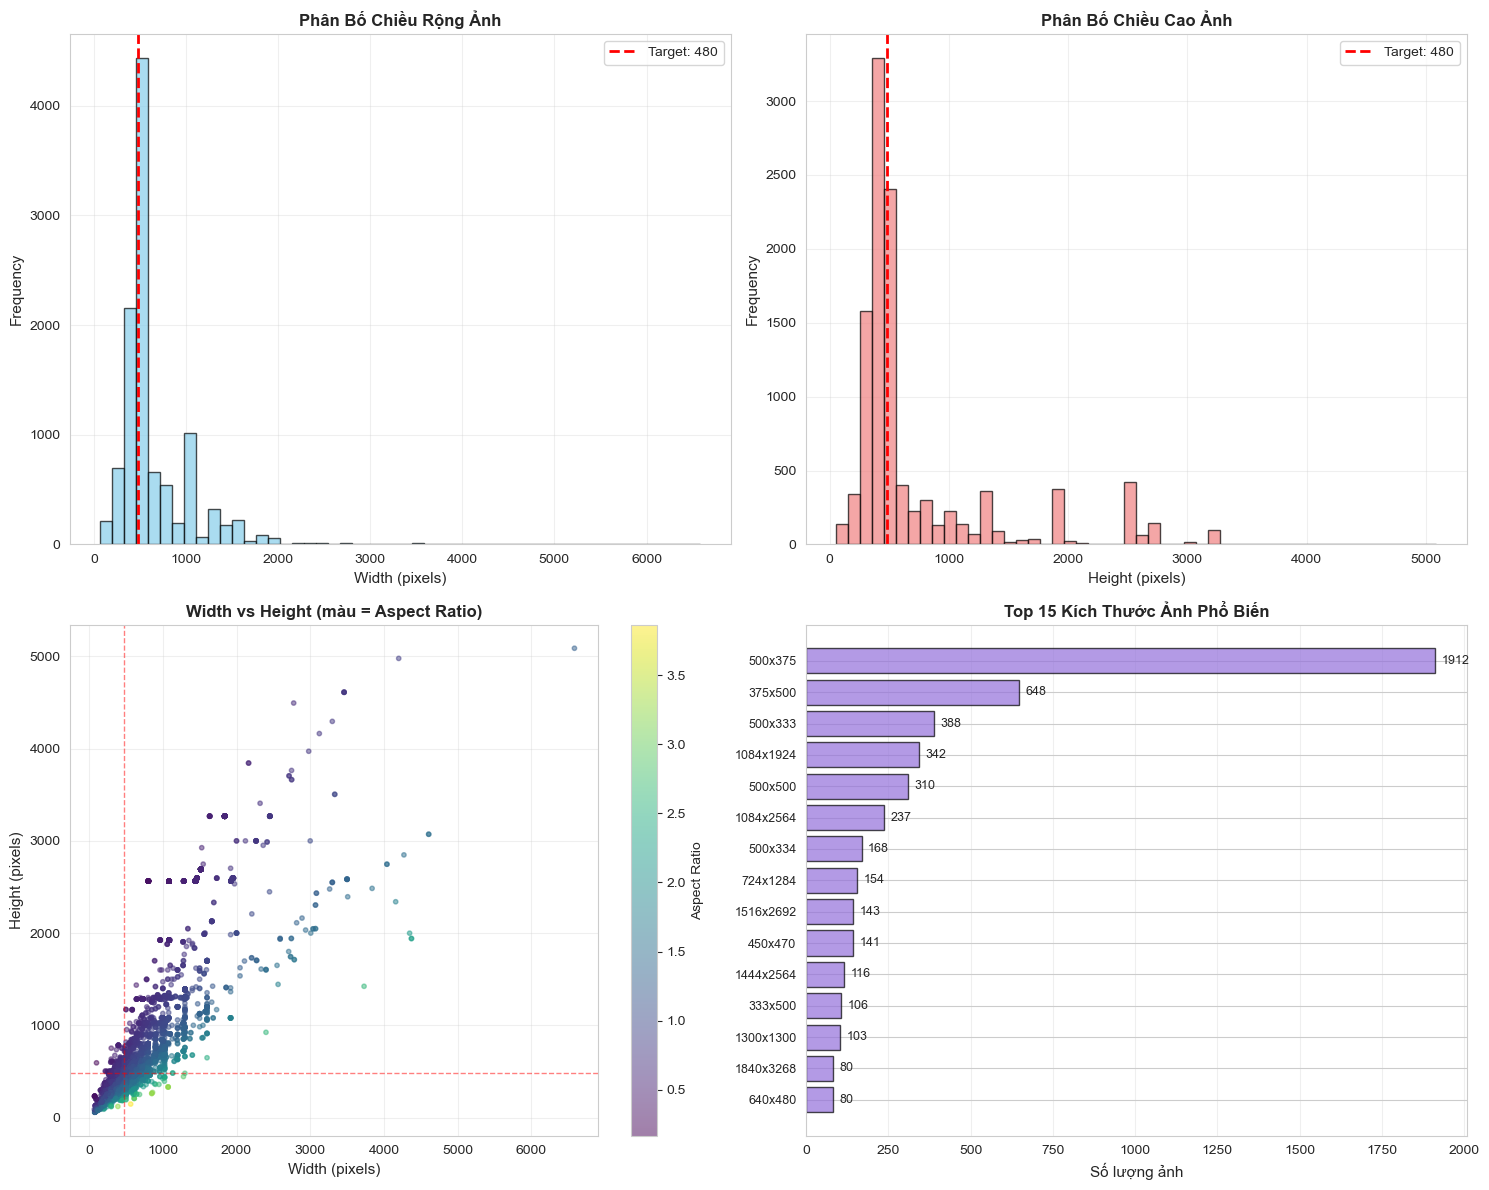

Visualizations created successfully!


In [11]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Histogram of widths
axes[0, 0].hist(widths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(480, color='red', linestyle='--', linewidth=2, label='Target: 480')
axes[0, 0].set_xlabel('Width (pixels)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Phân Bố Chiều Rộng Ảnh', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Histogram of heights
axes[0, 1].hist(heights, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(480, color='red', linestyle='--', linewidth=2, label='Target: 480')
axes[0, 1].set_xlabel('Height (pixels)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Phân Bố Chiều Cao Ảnh', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Scatter plot of width vs height with aspect ratio
scatter = axes[1, 0].scatter(widths, heights, c=aspect_ratios, cmap='viridis', alpha=0.5, s=10)
axes[1, 0].axhline(480, color='red', linestyle='--', alpha=0.5, linewidth=1)
axes[1, 0].axvline(480, color='red', linestyle='--', alpha=0.5, linewidth=1)
axes[1, 0].set_xlabel('Width (pixels)', fontsize=11)
axes[1, 0].set_ylabel('Height (pixels)', fontsize=11)
axes[1, 0].set_title('Width vs Height (màu = Aspect Ratio)', fontsize=12, fontweight='bold')
cbar = plt.colorbar(scatter, ax=axes[1, 0])
cbar.set_label('Aspect Ratio', fontsize=10)
axes[1, 0].grid(alpha=0.3)

# 4. Top 15 sizes
top_n = 15
top_indices = sorted_indices[:top_n]
top_sizes = unique_sizes[top_indices]
top_counts = counts[top_indices]

size_labels = [f"{int(s[0])}x{int(s[1])}" for s in top_sizes]
y_pos = np.arange(len(size_labels))

axes[1, 1].barh(y_pos, top_counts, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1, 1].set_yticks(y_pos)
axes[1, 1].set_yticklabels(size_labels, fontsize=9)
axes[1, 1].set_xlabel('Số lượng ảnh', fontsize=11)
axes[1, 1].set_title(f'Top {top_n} Kích Thước Ảnh Phổ Biến', fontsize=12, fontweight='bold')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(alpha=0.3, axis='x')

# Add count labels
for i, count in enumerate(top_counts):
    axes[1, 1].text(count + 20, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Visualizations created successfully!")

<!-- @format -->

## 5. Transformation Pipeline của EfficientNet-V2-L

### Quy trình xử lý ảnh:

```python
transforms.Compose([
    transforms.Resize(512),           # Bước 1: Resize thành 512x512
    transforms.CenterCrop(480),       # Bước 2: Crop chính giữa 480x480
    transforms.ToTensor(),            # Bước 3: Chuyển thành tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # Bước 4: Normalize theo ImageNet
        std=[0.229, 0.224, 0.225]
    )
])
```

### Cách hoạt động:

**1. Resize(512)**

- Ảnh bất kì kích thước nào sẽ được resize về 512x512
- Giữ nguyên aspect ratio, padding với background nếu cần
- Đảm bảo không bị méo mó

**2. CenterCrop(480)**

- Cắt phần giữa của ảnh 512x512 thành 480x480
- Bỏ đi 16 pixels ở mỗi cạnh (32 pixels từ width/height tổng cộng)
- Giữ được phần quan trọng nhất ở giữa ảnh

**3. Normalize**

- Chuẩn hóa theo mean/std của ImageNet
- Phục vụ cho model được training trên ImageNet
